# Часть 1. Проверка гипотезы в Python и составление аналитической записки <a id="part-1"></a>

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Проверка гипотезы об активности пользователей Москвы и Санкт‑Петербурга <a id="hyp-activity"></a>


- Автор: Жданова Мария
- Дата: 01.07.2026

## Цели и задачи проекта <a id="goals-tasks"></a>


<font color='#777778'>В этом блоке перечислите цель проекта и те задачи, которые вы решаете. Можно использовать описания проекта, но будет полезно, если вы сформулируете основную цель проекта самостоятельно.</font> <br>
Проверить одностороннюю гипотезу с двумя выборками о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы с помощью статистического теста.

## Описание данных <a id="тест"></a>

<font color='#777778'>Здесь приведите описание данных.</font> <br>
Файл yandex_knigi_data.csv содержит данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности.
* city — город пользователя (Москва или Санкт-Петербург);
* puid — идентификатор пользователя;
* hours — общее количество часов активности.

## Содержимое проекта

<font color='#777778'>Перечислите основные шаги проекта или напишите оглавление. Используйте описание проекта, чтобы зафиксировать основные шаги.</font>

---

- Часть 1. Проверка гипотезы в Python и составление аналитической записки
  - Проверка гипотезы об активности пользователей Москвы и Санкт‑Петербурга
  - Цели и задачи проекта
  - Описание данных
  - Содержимое проекта
  - Загрузка данных и знакомство с ними
  - Проверка гипотезы в Python
  - Аналитическая записка
- Часть 2. Анализ результатов A/B‑тестирования
  - Опишите цели исследования
  - Загрузите данные, оцените их целостность
  - По таблице ab_test_participants оцените корректность проведения теста
  - Проведите оценку результатов A/B‑тестирования

## Описание данных <a id="data-desc"></a>

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
#импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import zt_ind_solve_power

In [2]:
df_yandex = pd.read_csv('/datasets/yandex_knigi_data.csv')

In [3]:
#проверим дубликаты
df_yandex.duplicated(['puid']).sum()

244

In [4]:
#удалим дубликаты из puid
df_yandex = df_yandex.drop_duplicates(['puid']).reset_index(drop=True)

In [5]:
#сравним размеры групп
group_a = df_yandex[df_yandex['city'] == 'Москва']['puid'].nunique()
group_b = df_yandex[df_yandex['city'] == 'Санкт-Петербург']['puid'].nunique()
print(group_a)
print(group_b)

#считаем процентную разницу
percent_diff_a_b = round(100 * ((abs(group_a - group_b)) / group_a),4)
print(percent_diff_a_b)

6234
2306
63.0093


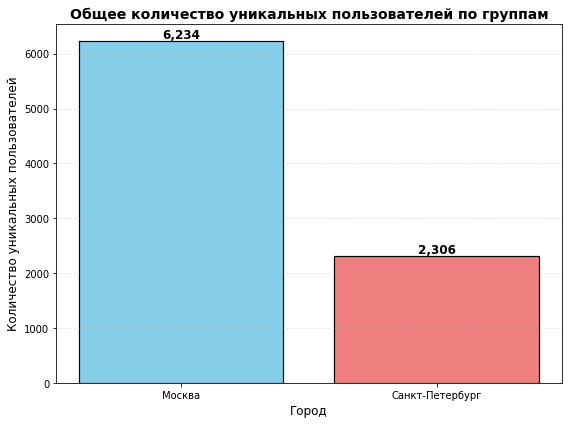

In [6]:
#строим график
groups = ['Москва', 'Санкт-Петербург']
values = [group_a, group_b]
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(8, 6))
bars = plt.bar(groups, values, color=colors, edgecolor='black', linewidth=1.2)

#добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:,}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Общее количество уникальных пользователей по группам', fontsize=14, fontweight='bold')
plt.xlabel('Город', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

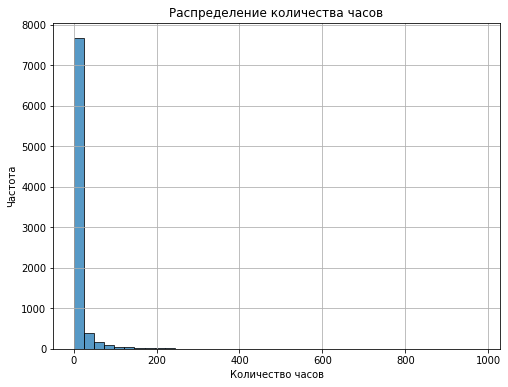

In [7]:
#проверим распределение кол-ва часов
plt.figure(figsize=(8, 6))

df_yandex['hours'].plot(
                kind='hist', 
                bins=40, 
                alpha=0.75,
                edgecolor='black',
)


plt.title('Распределение количества часов')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

plt.grid()
plt.show() 

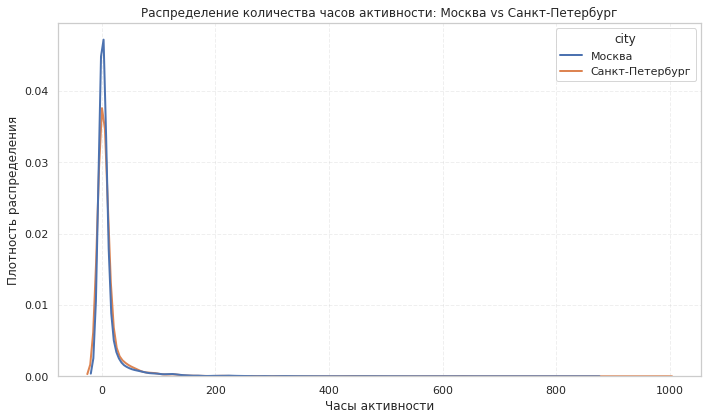

In [8]:
#проверим отличаются ли динамики кол-ва часов в каждой группе
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_yandex,
    x='hours',
    hue='city',
    fill=False,
    linewidth=2,
    common_norm=False
)

plt.title('Распределение количества часов активности: Москва vs Санкт-Петербург')
plt.xlabel('Часы активности')
plt.ylabel('Плотность распределения')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Динамики практически совпадают.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [9]:
metric_a = df_yandex[df_yandex.city == 'Москва']['hours']
metric_b = df_yandex[df_yandex.city == 'Санкт-Петербург']['hours']
alpha = 0.05
stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    metric_a, 
    metric_b, 
    equal_var=False,
    alternative='less'
) 

alpha = 0.05 

if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча = {round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение.')
    print('Интерпретация: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.')
else:
    print(f'p-value теста Уэлча = {round(p_value_welch_ttest, 2)}')
    print('Нулевую гипотезу опровергли.')
    print('Интерпретация: Средняя активность пользователей в Санкт-Петербурге больше.')

p-value теста Уэлча = 0.34
Нулевая гипотеза находит подтверждение.
Интерпретация: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



1. Выбранный тип t-теста - тест Уэлча, потому что это «безопасный» вариант независимого t‑теста, который не требует равенства дисперсий и чуть устойчивее к нарушениям нормальности, чем классический Стьюдент. А судя по графику распередления кол-ва часов это не совсем нормальнео распределение. Уровень статистической значимости 5%.
2. Р-value = 0.34, нулевая гипотеза подтверждена.
3. Интерпретация: средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.
4. Причины могут быть следующие:
* выборки могут пересекаться между собой, люди часто ездят между Москвой и Питером и могут читать и слушать книги в обоих городах.
* в Питере людей меньше, но это "культурная столица", поэтому меньшее кол-во людей в Питере проводит в приложении с книгами в среднем одинаково времени чем большее кол-во людей в Москве.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Провести оценку результатов A/B-теста новой версии сайта для магазина BitMotion Kit.

## 2. Загрузите данные, оцените их целостность.


In [10]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [11]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


Пропусков нет.

In [12]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Пропуски есть только в столбце details, но это не критично для оценки результатов теста.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [13]:
#чтобы выделить пользователей, участвующих в тесте, проверим какие тесты указаны в данных
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

Берем пользователей со значением interface_eu_test в столбце ab_test. Для этого соберем данные в новый датасет - df_part.

In [14]:
df_part = participants[participants['ab_test'] == 'interface_eu_test']

In [15]:
#проверим равномерность распределения пользователей по группам теста
#сравним размеры групп
part_group_a = df_part[df_part['group'] == 'A']['user_id'].nunique()
part_group_b = df_part[df_part['group'] == 'B']['user_id'].nunique()
print(part_group_a)
print(part_group_b)

#считаем процентную разницу
percent_diff_a_b_part = round(100 * ((abs(part_group_a - part_group_b)) / part_group_a),4)
print(percent_diff_a_b_part)

5383
5467
1.5605


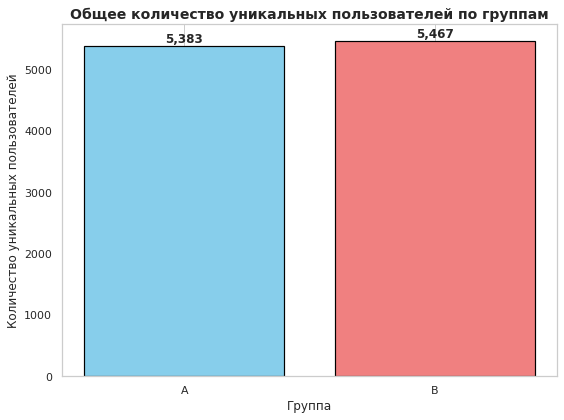

In [16]:
#строим график
groups = ['A', 'B']
values = [part_group_a, part_group_b]
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(8, 6))
bars = plt.bar(groups, values, color=colors, edgecolor='black', linewidth=1.2)

#добавляем подписи значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{height:,}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Общее количество уникальных пользователей по группам', fontsize=14, fontweight='bold')
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
#проверяем отсутствие пересечений в группах в тесте interface_eu_test, данные берем из df_part
part_gr_a = df_part[df_part['group'] == 'A']['user_id']
part_gr_b = df_part[df_part['group'] == 'B']['user_id']

intersection_part = list(set(part_gr_a) & set(part_gr_b))
print(intersection_part)

[]


In [18]:
#проверяем отсутствие пересечений с конкурирующим тестом
#данные берем из исходного датасета participants

gr_a = participants[participants['ab_test'] == 'interface_eu_test']['user_id']
gr_b = participants[participants['ab_test'] == 'recommender_system_test']['user_id']

intersection = list(set(gr_a) & set(gr_b))
print(intersection) 

['4C3B9B6D59E98D59', '669F197DC7EB4FD9', '4CF756542084F860', 'E17D1ABC377C38CA', 'CBEFCA3BFDE4CC58', 'A1C3D3C6C3CADDC5', '8D406B3B500671BD', '123C3AC236BE84F0', '803230F1D8216380', '81AA83FBC31B6C0B', '5D5E6EE92AF6E9E0', '934134714E66295F', 'E3481D64A20DA394', 'B0244412983000C5', '7AFFAFC4121EB5B2', 'B8AC521CB28510E7', 'D5DD44281759F7C8', '891458DEF142C0A3', '5D72D0AEF96C50FD', 'A8533224E9384B16', 'C226A7A3002ED8BE', '2ED365A23D725DB0', 'E1EA339E17C0D568', '3D1A366EDDC82832', '8FFA1D6F89AAEA40', 'E8BBE017F65D7CEA', 'DABC14FDDFADD29E', '8FA915CDB5994BDC', 'EB215155BA578253', '739656E0D7B50B30', '5461DD0AF191F581', 'DFE341550729F28E', 'FEC0BCA6C323872F', '5C7F53937B54D161', 'CF849D6380A28CA9', '495E506B3D29645B', '9431D6C9475CFD3A', '2F46396B6766CFDB', 'BF1EB8E6FA3F19B8', '2D7AF97EEB0056A5', '944C88D5DF108AED', 'BEF16764A13AEC34', '84F840D269A65875', '66821339106C8891', '95401934D6D6D4FC', '19AC976D25997BE9', 'D18A013DBEEB0951', '24FB1A84E1C30291', '6E3E5F88B6A3B401', '79BED20696125731',

In [19]:
#посчитаем сколько юзеров попалов тестовые группы обоих тестов 
#и какую долю от всей тестовой группы нашего основного теста они составляют
intersection_total = len(intersection)
id_total = participants['user_id'].nunique()
intersection_ratio = round((intersection_total/ id_total) * 100,4)
print(f' Доля пользователей, участвующих в обоих тестах: {intersection_ratio}%')

 Доля пользователей, участвующих в обоих тестах: 6.5039%


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [20]:
#берем user_id в events, которые совпадают с user_id в df_part, датасету где только по текущему тесту пользователи
#сохраняем результат в датасет events_fil
events_fil = events[events['user_id'].isin(df_part['user_id'])].copy()
events_fil.head()

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [21]:
#считаем лайфтайм

events_fil['event_dt'] = pd.to_datetime(events_fil['event_dt'], errors='coerce')

#получаем дату регистрации (самую первую) для каждого user_id
registrations = (
    events_fil[events_fil['event_name'] == 'registration']
    .groupby('user_id')['event_dt']
    .min()
    .reset_index()
    .rename(columns={'event_dt': 'registration_dt'})
)
registrations['registration_dt'] = pd.to_datetime(registrations['registration_dt'])

#присоединяем дату регистрации к основному датасету
events_with_lt = events_fil.merge(registrations, on='user_id', how='left')

#нормализуем даты 
events_with_lt['reg_date'] = events_with_lt['registration_dt'].dt.normalize()
events_with_lt['evt_date'] = events_with_lt['event_dt'].dt.normalize()

#считаем lifetime в днях
events_with_lt['lifetime_day'] = (events_with_lt['evt_date'] - events_with_lt['reg_date']).dt.days

#убираем строки, где нет регистрации
events_with_lt = events_with_lt.dropna(subset=['registration_dt'])

#оставляем только события в первые 7 дней 
events_7d = events_with_lt[(events_with_lt['lifetime_day'] >= 0) & 
                                 (events_with_lt['lifetime_day'] < 7)].copy() #v1 исправила тут знак на строго меньше

#проверям какие значения есть в поле lifetime_day

events_7d['lifetime_day'].value_counts()

0    35773
1    10572
2     6882
3     4980
4     3702
5     3257
6     2736
Name: lifetime_day, dtype: int64

In [22]:
# Код ревьюера
(events_7d.event_dt - events_7d.reg_date).max()

Timedelta('6 days 23:59:00')

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [23]:
#параметры:
alpha = 0.05
power = 0.8
p = 0.3

# MDE как 3 процентных пункта 
mde_absolute = 0.03
p_alt = p + mde_absolute

effect_size = proportion_effectsize(p, p_alt)

sample_size_per_group = zt_ind_solve_power(
    effect_size=effect_size,
    nobs1=None,
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

total_sample_needed = sample_size_per_group * 2

print(f"Необходимый размер выборки для каждой группы: {int(sample_size_per_group)}")
print(f"Общая необходимая выборка (обе группы): {int(total_sample_needed)}")



Необходимый размер выборки для каждой группы: 3761
Общая необходимая выборка (обе группы): 7523


In [24]:
#присоединяем датасет events_7d к датасету df_part и создаем общий датасет merge_df

merge_df = events_7d.merge(df_part, on='user_id', how='inner')
merge_df.head()

,user_id,event_dt,event_name,details,registration_dt,reg_date,evt_date,lifetime_day,group,ab_test,device
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,2020-12-06,2020-12-06,0,A,interface_eu_test,iPhone
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,2020-12-06 14:10:01,2020-12-06,2020-12-07,1,A,interface_eu_test,iPhone
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,2020-12-06 14:10:01,2020-12-06,2020-12-07,1,A,interface_eu_test,iPhone
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,2020-12-06 14:10:01,2020-12-06,2020-12-09,3,A,interface_eu_test,iPhone
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,2020-12-06 14:10:01,2020-12-06,2020-12-09,3,A,interface_eu_test,iPhone


In [25]:
#считаем сколько пользователей в каждой группе, чтобы сравнить с результатами теста выше
merge_gr_a = merge_df[merge_df['group'] == 'A']['user_id'].nunique()
merge_gr_b = merge_df[merge_df['group'] == 'B']['user_id'].nunique()
print(f'Кол-во пользователей в группе А: {merge_gr_a}')
print(f'Кол-во пользователей в группе B: {merge_gr_b}')
if int(sample_size_per_group) <= merge_gr_a:
    print('В группе А достаточно пользователей для получения статистически значимых результатов A/B-теста')
else:
    print('Пользователей в группе А недостаточно')

    
if int(sample_size_per_group) <= merge_gr_b:
    print('В группе В достаточно пользователей для получения статистически значимых результатов A/B-теста')
else:
    print('Пользователей в группе B недостаточно')

Кол-во пользователей в группе А: 5383
Кол-во пользователей в группе B: 5467
В группе А достаточно пользователей для получения статистически значимых результатов A/B-теста
В группе В достаточно пользователей для получения статистически значимых результатов A/B-теста


In [26]:
merge_df['event_name'].value_counts()

login           28729
product_page    15943
registration    10850
purchase         6290
product_cart     6090
Name: event_name, dtype: int64

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [27]:
#общее количество посетителей рассчитано в переменных merge_gr_a и merge_gr_b
#считаем по группам сколько сделали покупку
a_purchase = (merge_df[(merge_df['group'] == 'A') & (merge_df['event_name'] == 'purchase') ]['user_id'].nunique())    
b_purchase = (merge_df[(merge_df['group'] == 'B') & (merge_df['event_name'] == 'purchase') ]['user_id'].nunique())
#считаем долю покупок по группам (конверсию)
a_purchase_ratio = round((a_purchase / merge_gr_a) * 100,4)
b_purchase_ratio = round((b_purchase / merge_gr_b) * 100,4)
print(a_purchase_ratio)
print(b_purchase_ratio)
diff_ratio = round(b_purchase_ratio - a_purchase_ratio,2)
print (f'Группа B сделала покупок на {diff_ratio}% больше группы А')


26.8995
28.3885
Группа B сделала покупок на 1.49% больше группы А


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Группа B сделала покупок на 1.49% больше группы А

Отметим, что прирост конверсии есть, но он не соответствует запланированному приросту в 3 процентных пункта. 

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Гипотезы:
* H_0: Новая версия сайта повысила конверсию (кол-во пользователей, совершивших покупку), и это статистически НЕ значимо.
* H_1: Новая версия сайта повысила конверсию (кол-во пользователей, совершивших покупку), и это статистически значимо.

In [28]:
n_a = merge_df[merge_df.group == 'A'].shape[0]
n_b = merge_df[merge_df.group == 'B'].shape[0]

m_a = merge_df[(merge_df.group == 'A')&(merge_df.event_name == 'purchase')].shape[0]
m_b = merge_df[(merge_df.group == 'B')&(merge_df.event_name == 'purchase')].shape[0]

p_a, p_b = m_a/n_a, m_b/n_b

if (p_a*n_a > 10)and((1-p_a)*n_a > 10)and(p_b*n_b > 10)and((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется.')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется.')

alpha = 0.05 


stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' #так как H_1: p_a < p_b
)

print(f'pvalue={p_value_ztest}') 
if p_value_ztest > alpha:
    print('Нулевая гипотеза подтверждается.')
    print('Новая версия сайта повысила конверсию, и это статистически НЕ значимо.')
else:
    print('Нулевая гипотеза опровергается.')
    print('Новая версия сайта повысила конверсию, и это z-тест.')   

Предпосылка о достаточном количестве данных выполняется.
pvalue=2.0995322680649603e-17
Нулевая гипотеза опровергается.
Новая версия сайта повысила конверсию, и это z-тест.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

* Для проверки результатов A/B-теста был использован Z-тест пропорций.
* pvalue=2.852837035631668e-23, что больше уровня значимости, поэтому альтернативная гипотеза подвердилась, действительно новая версия сайта повысила количество пользователей, которые совершили покупку.
* Ожидаемый эффект в изменении конверсии достигнут.